In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
# 1. Load the dataset
df = pd.read_csv('CC GENERAL.csv')


In [5]:

# 2. Preprocessing
# Drop the categorical identifier
X = df.drop('CUST_ID', axis=1)

# Handle missing values by imputing the median
X['CREDIT_LIMIT'] = X['CREDIT_LIMIT'].fillna(X['CREDIT_LIMIT'].median())
X['MINIMUM_PAYMENTS'] = X['MINIMUM_PAYMENTS'].fillna(X['MINIMUM_PAYMENTS'].median())

# Standardize the features so they are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Determine Optimal Clusters (Elbow Method)


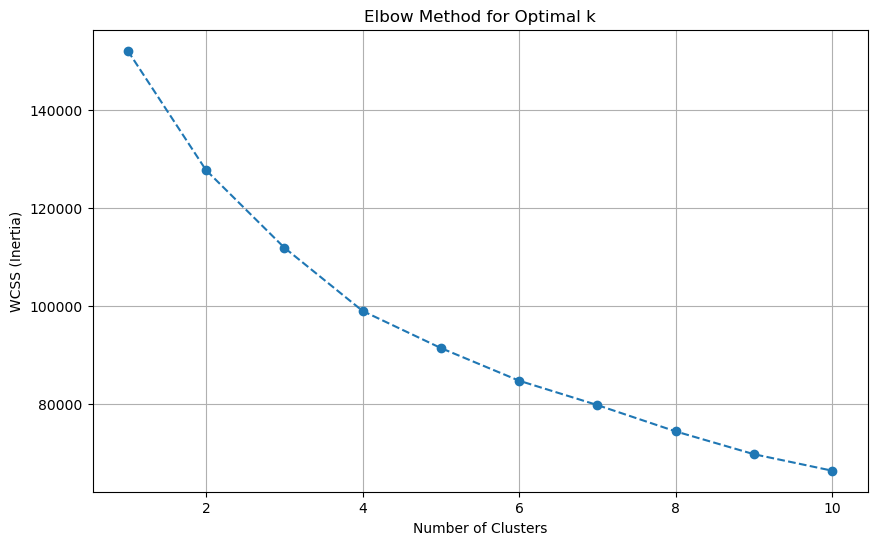

In [7]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.savefig('elbow_method.png')


In [9]:
# 4. Apply K-Means Clustering
# We chose k=4 based on the elbow observation and segment interpretation
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the original dataframe
df['Cluster'] = cluster_labels



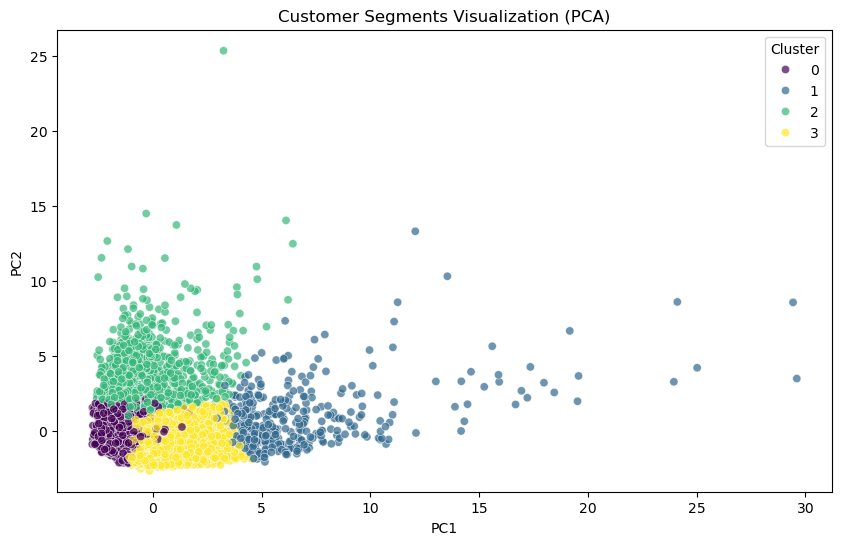

In [11]:
# 5. Dimensionality Reduction for Visualization (PCA)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

# Plot the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.7)
plt.title('Customer Segments Visualization (PCA)')
plt.savefig('clusters_visualization.png')



In [13]:
# 6. Analyze and Export Results
# Calculate mean values for each cluster to understand behavior
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cluster_stats = df.groupby('Cluster')[numeric_cols].mean()

# Save outputs
cluster_stats.to_csv('cluster_statistics.csv')
df.to_csv('CC_GENERAL_CLUSTERED.csv', index=False)

print("Clustering complete. Results saved to 'CC_GENERAL_CLUSTERED.csv' and 'cluster_statistics.csv'.")
print("\nCluster Means Summary:")
print(cluster_stats)

Clustering complete. Results saved to 'CC_GENERAL_CLUSTERED.csv' and 'cluster_statistics.csv'.

Cluster Means Summary:
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        1012.658327           0.789924   270.041785        209.937299   
1        3551.153761           0.986879  7681.620098       5095.878826   
2        4602.449658           0.968389   501.862982        320.188797   
3         894.907458           0.934734  1236.178934        593.974874   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                     60.371441    596.509903             0.170145   
1                   2587.208264    653.638891             0.946418   
2                    181.759123   4521.509581             0.287832   
3                    642.478274    210.570626             0.885165   

         ONEOFF